In [23]:
import matplotlib.pyplot as plt
import matplotlib
#matplotlib.rcParams['text.latex.preamble']=[r"\usepackage{amsmath}"]

import pandas as pd
import numpy as np
from scipy import interpolate
from scipy.integrate import simpson
#%matplotlib qt
import os
cwd = '/home/lurishi/Escritorio/HeavenlyMCP/'
path_to_style=cwd+'/Figures'

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

In [24]:
#--- Load the data
path=cwd+'/Data/MCP_flux/MCP_flux'
df_pi0_=pd.read_csv(path+r'/MCP_FROM_PI0_SURFACE.csv' )
df_eta_=pd.read_csv(path+r'/MCP_FROM_ETA_SURFACE.csv' )
df_omega_=pd.read_csv(path+r'/MCP_FROM_OMEGA_SURFACE.csv' )
df_rho_=pd.read_csv(path+r'/MCP_FROM_RHO_SURFACE.csv'  )
df_phi_=pd.read_csv(path+r'/MCP_FROM_PHI_SURFACE.csv' )
df_jpsi_=pd.read_csv(path+r'/MCP_FROM_JPSI_SURFACE.csv'  )

In [25]:
df_pi0_.head()

,dphi_dEdCth(1/GeV/s/cm2),Energy (GeV),cosTh,m(GeV),eps2
0,5.839666e-08,0.134970,0.0,0.05,0.01
1,2.848004e-08,0.193691,0.0,0.05,0.01
2,1.801280e-08,0.277960,0.0,0.05,0.01
3,1.205648e-08,0.398891,0.0,0.05,0.01
4,8.248841e-09,0.572436,0.0,0.05,0.01


In [26]:
# Elegimos el mismo epsilon para todos los mesones padre

eps2 = 1e-4


df_eta = df_eta_[df_eta_['eps2'] == eps2]
df_omega = df_omega_[df_omega_['eps2'] == eps2]
df_rho = df_rho_[df_rho_['eps2'] == eps2]
df_phi = df_phi_[df_phi_['eps2'] == eps2]
df_jpsi = df_jpsi_[df_jpsi_['eps2'] == eps2]


In [27]:
df = [df_eta, df_omega, df_rho, df_phi, df_jpsi]
masses = [df_eta['m(GeV)'].unique(),df_omega['m(GeV)'].unique(),df_rho['m(GeV)'].unique(),df_phi['m(GeV)'].unique(),df_jpsi['m(GeV)'].unique()] # GeV
len(masses)

5

In [29]:
flujo_md = []
# Loopea sobre los mesones
for i in range(len(masses)):
    mass = masses[i]
    flux = np.zeros(len(mass))
    # Loopea sobre las masas
    for j in range(len(mass)):
        E = df[i]['Energy (GeV)'][df[i]['m(GeV)'] == mass[j]].values
        dif_flux = df[i]['dphi_dEdCth(1/GeV/s/cm2)'][df[i]['m(GeV)'] == mass[j]].values
        # Sort by energy to ensure correct integration sign
        order = np.argsort(E)
        E_sorted = E[order]
        dif_sorted = dif_flux[order]
        # # Remove duplicate energy points (keep first of each unique E)
        # if E_sorted.size == 0:
        #     flux[j] = 0.0
        #     continue
        # unique_mask = np.concatenate(([True], np.diff(E_sorted) != 0))
        # E_u = E_sorted[unique_mask]
        # dif_u = dif_sorted[unique_mask]
        # # If not enough points to integrate, set flux to 0
        # if E_u.size < 2:
        #     flux[j] = 0.0
        #     continue
        # # Ensure integrand is non-negative (physical constraint)
        # dif_u = np.clip(dif_u, 0, None)
        flux[j] = simpson(dif_sorted, E_sorted)/2*np.pi
    flujo_md.append(flux)

58


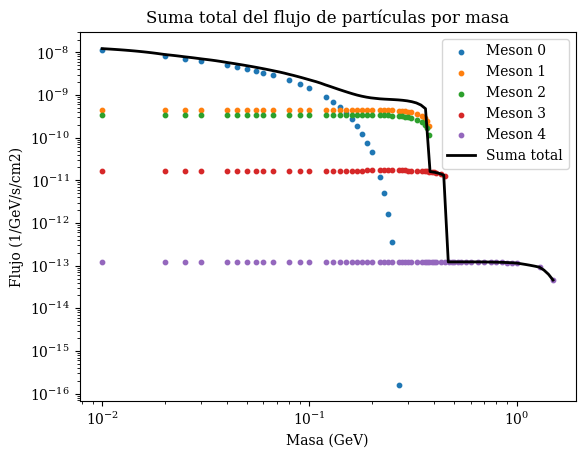

In [30]:
common_mass_ = np.unique(np.concatenate([np.asarray(m) for m in masses]))
print(len(common_mass_))
common_mass = np.logspace(np.log10(common_mass_[0]), np.log10(common_mass_[-1]), 100)

flujo_md_interp = []
for i in range(len(masses)):
    plt.scatter(masses[i], flujo_md[i], label=f'Meson {i}', s=10)
    mass_sorted_idx = np.argsort(masses[i])
    mass_sorted = np.asarray(masses[i])[mass_sorted_idx]
    flux_sorted = np.asarray(flujo_md[i])[mass_sorted_idx]

    unique_mask = np.concatenate(([True], np.diff(mass_sorted) != 0))
    mass_unique = mass_sorted[unique_mask]
    flux_unique = flux_sorted[unique_mask]

    flujo_md_interp.append(np.interp(common_mass, mass_unique, flux_unique, left=0.0, right=0.0))

flujo_total = np.sum(flujo_md_interp, axis=0)

plt.plot(common_mass, flujo_total, label='Suma total', color='black', linewidth=2)
plt.xlabel('Masa (GeV)')
plt.ylabel('Flujo (1/GeV/s/cm2)')
plt.title('Suma total del flujo de partículas por masa')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [31]:
df_lz = pd.read_csv('/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_MD_interpolado.csv')
df_lz_pi0 = pd.read_csv(
    '/home/lurishi/Escritorio/Doctorado/Mcp_gráficos_papers/Flujo_de_pi_0.csv',
    sep=';',
    header=None,
    names=['Masa[MeV/c2]', 'Flujo[s-1cm-2]'],
    decimal=','
)

In [32]:
print('df_lz columns:', df_lz.columns.tolist())
print('df_lz_pi0 columns:', df_lz_pi0.columns.tolist())

mass_col = 'Masa[MeV/c2]'
flux_col = 'Flujo[s-1cm-2]'

lz_sorted = df_lz.sort_values(mass_col)
pi0_sorted = df_lz_pi0.sort_values(mass_col)

# Usamos la malla de Lz y solo restamos pi0 donde ambos dominios se solapan
lz_mass = lz_sorted[mass_col].to_numpy()
lz_flux = lz_sorted[flux_col].to_numpy()

pi0_interp = np.interp(lz_mass, pi0_sorted[mass_col], pi0_sorted[flux_col]*2*np.pi, left=np.nan, right=np.nan)

overlap_mask = (
    (lz_mass >= lz_sorted[mass_col].min())
    & (lz_mass <= pi0_sorted[mass_col].max())
)

lz_diff = lz_flux.copy()
lz_diff[overlap_mask] = lz_flux[overlap_mask] - pi0_interp[overlap_mask]

print('lz size:', len(lz_mass))
print('overlap size:', overlap_mask.sum())
print('lz_diff head:', lz_diff[:5])

df_lz columns: ['Masa[MeV/c2]', 'Flujo[s-1cm-2]']
df_lz_pi0 columns: ['Masa[MeV/c2]', 'Flujo[s-1cm-2]']
lz size: 100
overlap size: 37
lz_diff head: [           nan 1.46954343e-08 1.42485031e-08 1.50699389e-08
 1.53805047e-08]


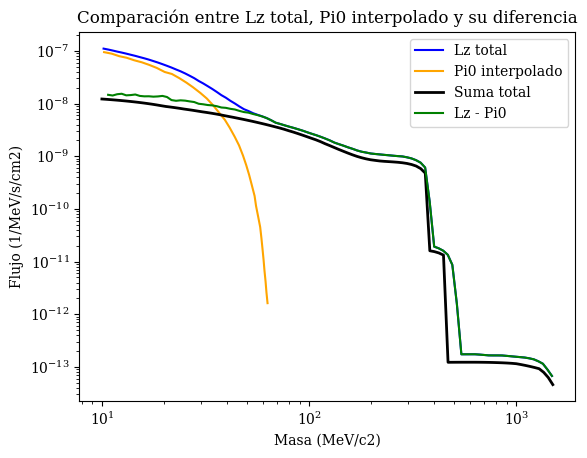

In [33]:
plt.plot(lz_mass, lz_flux, label='Lz total', color='blue')
plt.plot(pi0_sorted[mass_col].to_numpy(), pi0_sorted[flux_col].to_numpy()*2*np.pi, label='Pi0 interpolado', color='orange')
plt.plot(common_mass*1000, flujo_total, label='Suma total', color='black', linewidth=2)
plt.plot(lz_mass, lz_diff, label='Lz - Pi0', color='green')
plt.xlabel('Masa (MeV/c2)')
plt.ylabel('Flujo (1/MeV/s/cm2)')
plt.title('Comparación entre Lz total, Pi0 interpolado y su diferencia')
plt.xscale('log')
plt.yscale('log')
plt.legend()

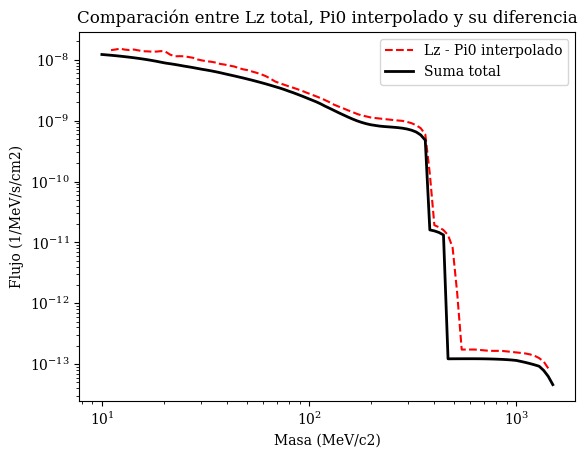

In [34]:
flujo_lz = np.interp(common_mass*1000, lz_mass, lz_diff, left=np.nan, right=np.nan)
plt.plot(common_mass*1000, flujo_lz, label='Lz - Pi0 interpolado', color='red', linestyle='--')
plt.plot(common_mass*1000, flujo_total, label='Suma total', color='black', linewidth=2) 
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa (MeV/c2)')
plt.ylabel('Flujo (1/MeV/s/cm2)')
plt.title('Comparación entre Lz total, Pi0 interpolado y su diferencia')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [36]:
flujo_lz/flujo_total

array([         nan,          nan,   1.2137787 ,   1.26449027,
         1.32995187,   1.30579354,   1.30946012,   1.36551137,
         1.35248722,   1.34106602,   1.37200291,   1.39720646,
         1.44455397,   1.52321719,   1.53245002,   1.41057876,
         1.36058557,   1.40846534,   1.44759795,   1.44860877,
         1.44870312,   1.40435298,   1.39718312,   1.39482908,
         1.41106128,   1.41466469,   1.39465261,   1.41562652,
         1.41806115,   1.42584166,   1.40542802,   1.38692348,
         1.40308885,   1.38980649,   1.38272834,   1.36998209,
         1.33979275,   1.28435588,   1.2165444 ,   1.20049509,
         1.19571244,   1.20110397,   1.20568197,   1.21282658,
         1.21826903,   1.21922958,   1.22280702,   1.22953364,
         1.2394877 ,   1.25696868,   1.25596767,   1.24503729,
         1.26239933,   1.27933684,   1.28827933,   1.30202145,
         1.29861504,   1.30256936,   1.31758372,   1.31688499,
         1.32354292,   1.33221004,   1.32769372,   1.32